In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import xarray as xr 
import matplotlib.pyplot as plt

import sys
import os
DIR = "/Users/knv2/Documents/codebase/AFL-tutorial/3DPhaseDiagram"
folders = [DIR+"/modules/", DIR+ "/dataset/", DIR+"/benchmarking/"]
for path in folders:
    if path not in sys.path:
        sys.path.append(path)

from cost import DesignSpaceHierarchyCost, BinaryProbabilityCost, UtilityWithCost, SlicedCost, MarginalCost
from utility import MarginalEntropyOverDimension 
from query_strategy import ArgMax, MinMax1DLineSampler 
from helpers import *
from pipelines import FeasibilityLabeler, ExperimentCost 

from AFL.double_agent.PyTorchExtrapolator import DirichletGPExtrapolator 
from AFL.double_agent.Pipeline import Pipeline 
from AFL.double_agent.Generator import CartesianGrid 
from AFL.double_agent.Preprocessor import Standardize 

In [3]:
expense = ExperimentCost(
        input_variable="design_space",
        input_dim="ds_dim",
        composition_dims_cost={"protein":10.0, "glycerol" :5.0},
        temperature_dim_cost={"temperature" : 20.0},
        output_variable="expense",
        name="ExperimentCost"
    ) 

In [4]:
sim = get_simulator("../dataset/")

In [5]:
ds_list = []
protein_init = np.random.uniform(low=0.0, high=80.0)
glycerol_init = np.random.uniform(low=0.0, high=12.0)
for temp in [0,10,20,30,40,50]:
    ds = sim.simple_expose({'protein':protein_init,'temperature':temp,'glycerol':glycerol_init})
    ds = ds.rename({'composition': 'design_space', 'component':'ds_dim'})
    ds['phases'] = int(ds.attrs['labels'])
    ds['step'] = 0
    ds_list.append(ds)

ds_init = xr.concat(ds_list, dim='sample')
ds_running = ds_init.copy() 

In [6]:
gp_params_mcmc = {"num_samples":20, "num_warmup":20, "method":"mcmc", "verbose":False} 

In [7]:
with Pipeline(name = "phase_boundaries") as p:
    CartesianGrid(
        output_variable="design_space_grid",
        sample_dim="ds_grid",
        component_dim ="ds_dim",
        grid_spec = {'protein':{'min': 0.0, 'max': 80.0, 'steps': 20},
                    'glycerol':{'min': 0.0, 'max': 12.0, 'steps': 20},
                    'temperature':{'min': 0.0, 'max': 50.0, 'steps': 20}}
    )    
    Standardize(
        input_variable="design_space",
        output_variable="normalized_design_space",
        dim="sample",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )
    Standardize(
        input_variable="design_space_grid",
        output_variable="normalized_design_space_grid",
        dim="ds_grid",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )
    DirichletGPExtrapolator(
        feature_input_variable="normalized_design_space",
        predictor_input_variable="phases",
        output_prefix="phase",
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        sample_dim="sample",
        component_dim = "ds_dim",
        params=gp_params_mcmc,
        name="DirichletGPExtrapolator-PhaseLabels",
    )
    FeasibilityLabeler(
        input_variable="phases",
        output_variable="feasibility_labels",
        dim="sample",
        name="FeasibilityLabeler",
    )
    DirichletGPExtrapolator(
        feature_input_variable="normalized_design_space",
        predictor_input_variable="feasibility_labels",
        output_prefix="feasibility",
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        sample_dim="sample",
        component_dim = "ds_dim",
        params=gp_params_mcmc,
        name="DirichletGPExtrapolator-FeasibilityLabels",
    )
    MarginalEntropyOverDimension(
        input_variable= "phase_y_prob",
        coordinate_dims= ['temperature'],
        component_dim= "ds_dim",
        grid_variable= "design_space_grid",        
        output_variable="composition_utility",
        name= "UtilityMarginalEntropy",
    )
    DesignSpaceHierarchyCost(
        input_variable = "normalized_design_space_grid",
        grid_variable = "design_space_grid",
        grid_dim = "ds_grid",
        component_dim = "ds_dim",
        coordinates_order = ['temperature', 'protein', 'glycerol'], # from highest to lowest cost
        coordinates_offsets = [0.5, 0.0, 0.0],
        output_variable="hierarchy_cost",
        name = "DesignSpaceHierarchyCost",        
    )
    MarginalCost(
        input_variable = "hierarchy_cost",
        coordinate_dims = ['temperature'],
        component_dim = "ds_dim",
        grid_variable = "design_space_grid",
        output_variable="composition_hierarchy_cost",
        name= "MarginalCost",
    )    
    UtilityWithCost(
        input_variable = "composition_utility",
        cost_variables = ["composition_hierarchy_cost"],
        output_variable = "composition_utility_with_cost",
        name = "AcquisitonWithCost-Composition",
    )
    ArgMax(
        input_variable="composition_utility_with_cost",
        grid_variable="_".join(i for i in ['protein', 'glycerol'])+"_domain",
        output_prefix= "composition",
        name= "QueryStrategyCompositionSpace",
    )
    BinaryProbabilityCost(
        input_variable="feasibility_y_prob",
        grid_variable = "design_space_grid",
        cost_label = 1,
        dim="ds_grid",
        output_variable = "feasibility_cost",
        name = "BinaryProbabilityCost"
    )  
    SlicedCost(
        input_variable = "feasibility_cost",
        conditioning_point = "composition_next",
        coordinate_dim = "temperature",
        grid_variable = "design_space_grid",        
        component_dim = "ds_dim",
        output_variable = "temperature_utility",
        name = "SlicedUtility-Temperature",
    )
    MinMax1DLineSampler(
        input_variable= "temperature_utility",
        grid_variable= "temperature_domain",
        min_value= 0.33,
        max_value= 1.0,
        n_samples = 5,
        output_prefix ="temperature",
        name = "TemperatureLineSampler",
        )
       
p.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <CartesianGridGenerator>            CartesianGridGenerator ---> design_space_grid
1  ) <Standardize>                       design_space ---> normalized_design_space
2  ) <Standardize>                       design_space_grid ---> normalized_design_space_grid
3  ) <DirichletGPExtrapolator-PhaseLabels> ['normalized_design_space', 'phases', 'normalized_design_space_grid'] ---> ['phase_y_prob']
4  ) <FeasibilityLabeler>                phases ---> feasibility_labels
5  ) <DirichletGPExtrapolator-FeasibilityLabels> ['normalized_design_space', 'feasibility_labels', 'normalized_design_space_grid'] ---> ['feasibility_y_prob']
6  ) <UtilityMarginalEntropy>            phase_y_prob ---> composition_utility
7  ) <DesignSpaceHierarchyCost>          normalized_design_space_grid ---> hierarchy_cost
8  ) <MarginalCost>                      hierarc

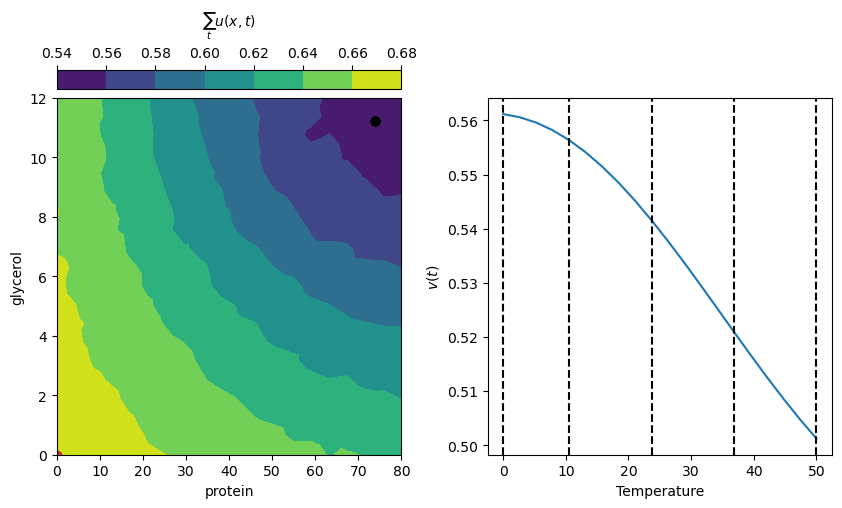

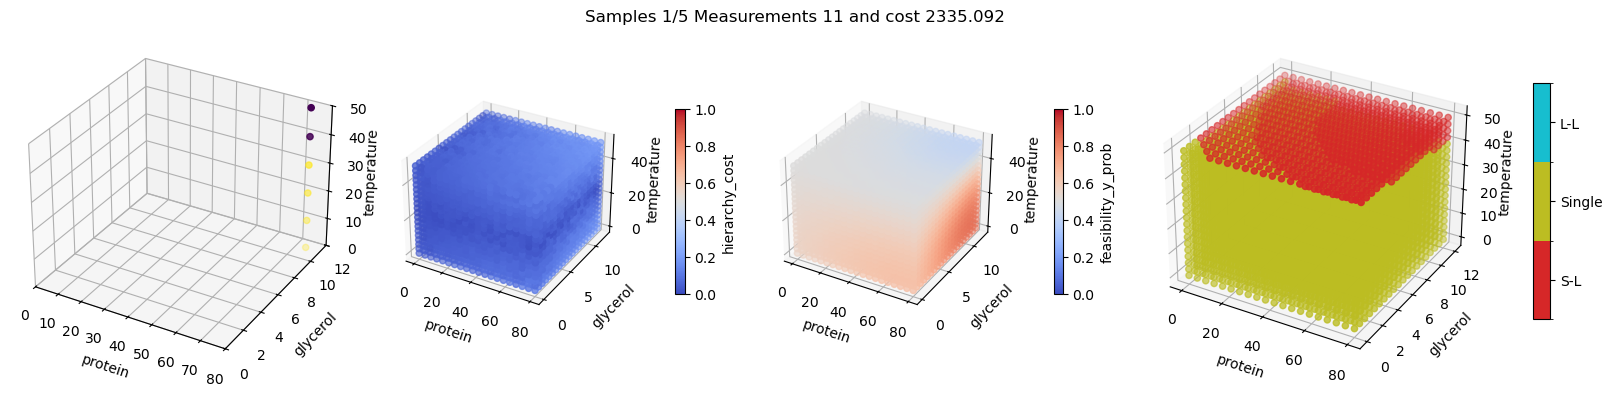

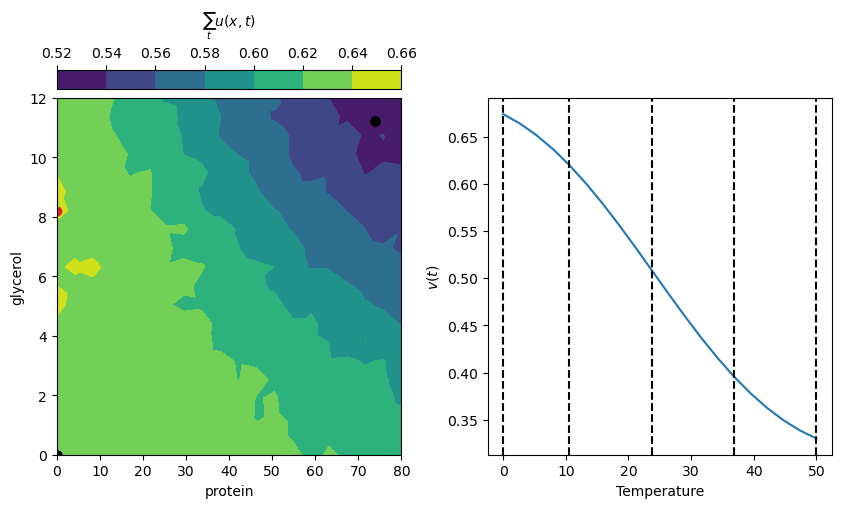

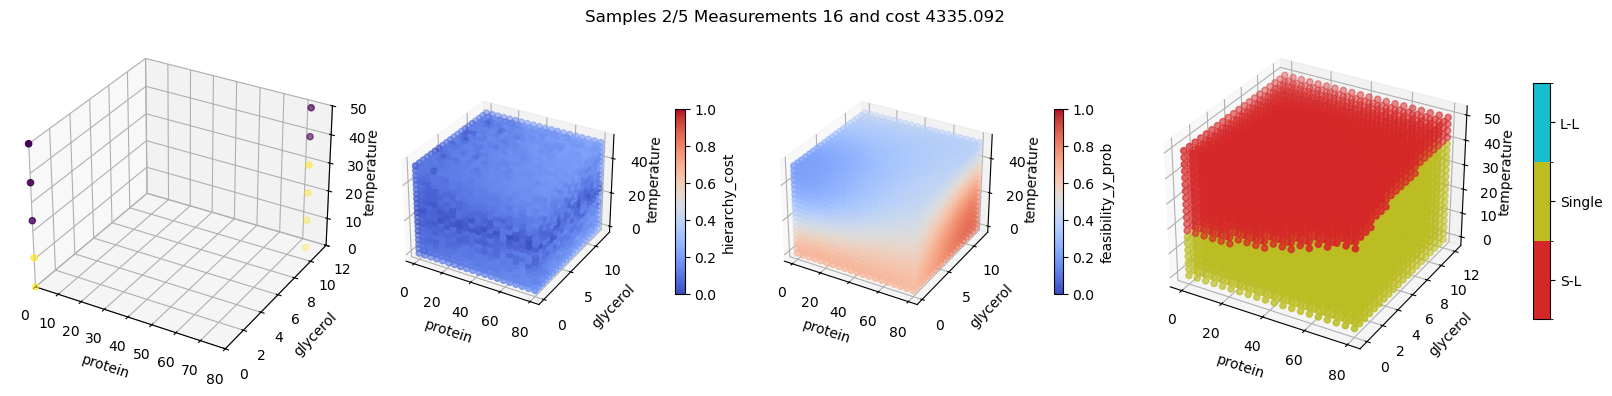

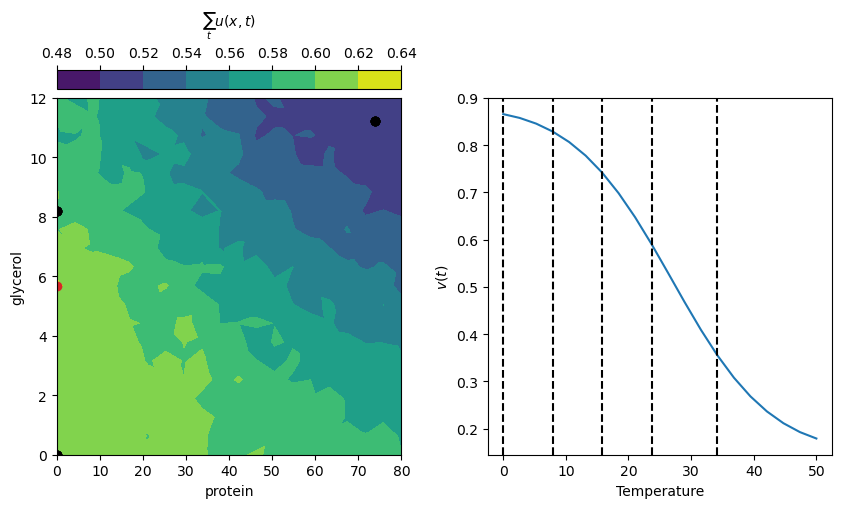

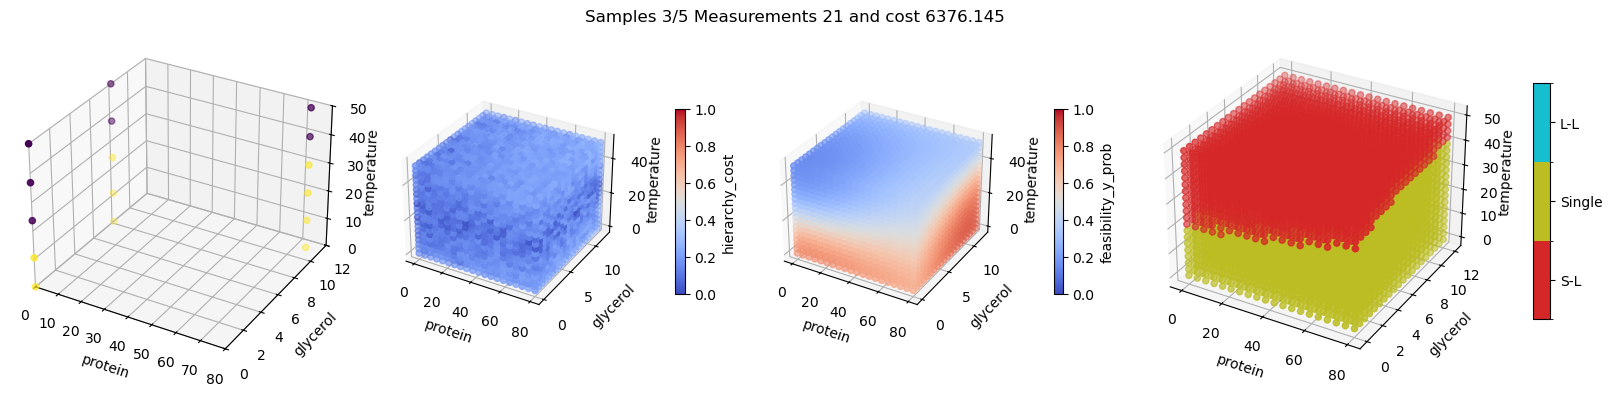

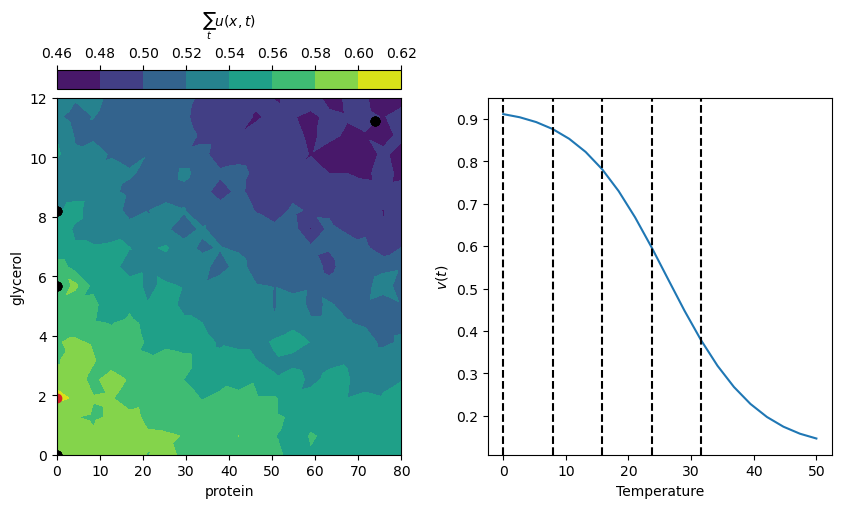

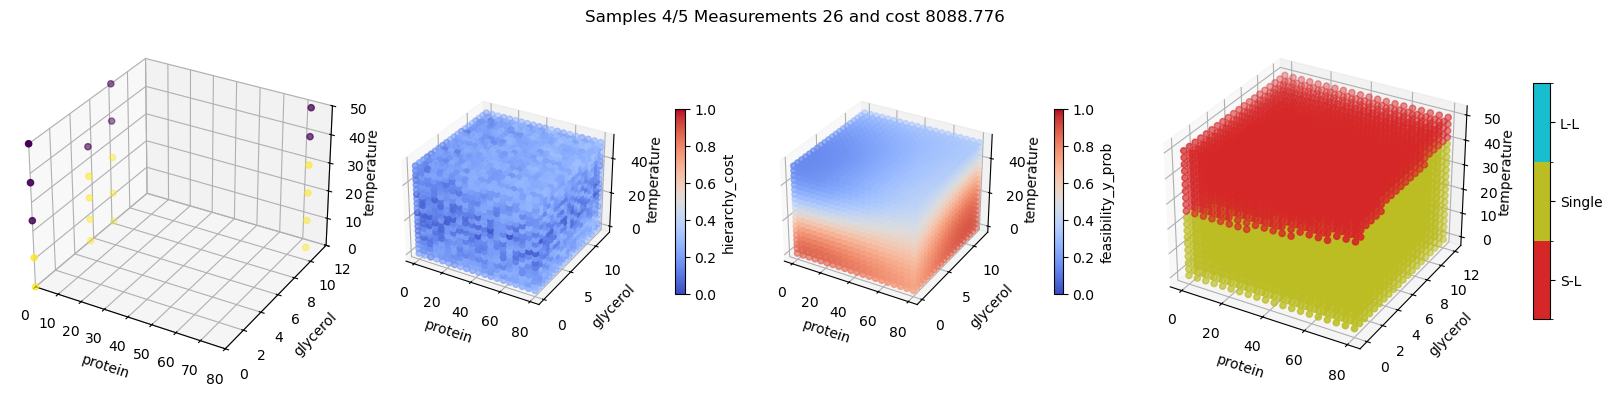

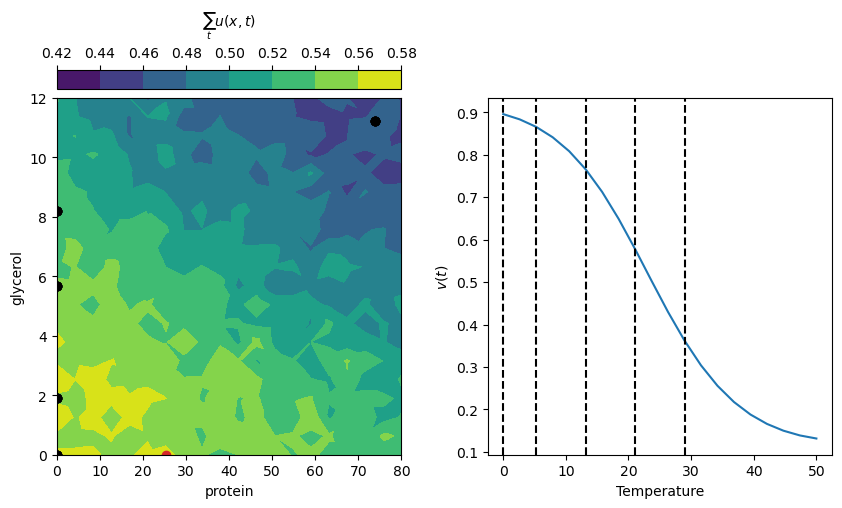

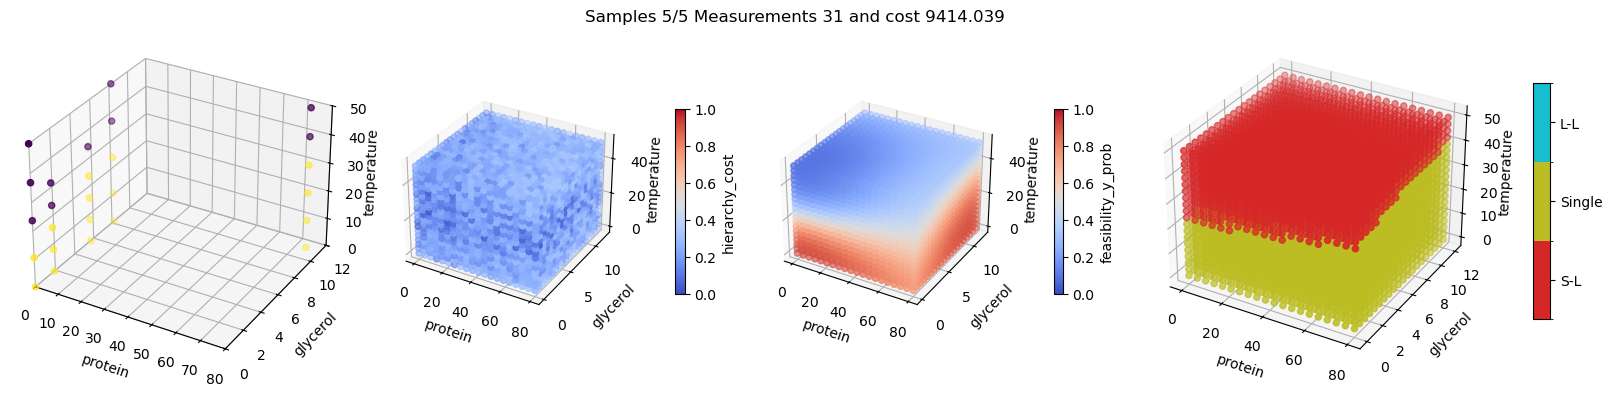

In [8]:
ds_running = ds_init.copy() 
num_samples = 5

for step in range(num_samples):
    ds_result = p.calculate(ds_running, disable_progress_bar=True)
    ds_new = []
    for t in ds_result.temperature_next.values:
        sample = {"protein": ds_result.composition_next.sel({"protein_glycerol_d":"protein"}).values.item(),
                "glycerol" : ds_result.composition_next.sel({"protein_glycerol_d":"glycerol"}).values.item(),
                "temperature" : t.item()
        }  
        ds = sim.simple_expose(sample)
        ds = ds.rename({'composition': 'design_space', 'component':'ds_dim'})
        ds['phases'] = int(ds.attrs['labels'])
        ds_new.append(ds)

    ds_new = xr.concat(ds_new, dim='sample')
    ds_running = xr.concat([ds_running, ds_new], dim='sample')
    
    out = expense.calculate(ds_result)

    plot_sampling(ds_result,
                  "design_space",
                  "ds_dim",
                  "_".join(i for i in ['protein', 'glycerol'])+"_domain",
                  "composition_utility_with_cost",
                  "composition_next",
                  "temperature_domain",
                  "temperature_utility",
                  "temperature_next"
            )
    plt.show()

    fig, axs = plot_progress(ds_result, 
                "design_space", 
                "design_space_grid", 
                "ds_dim", 
                ['protein', 'glycerol'],
                "temperature",
                "phases",
                "hierarchy_cost",
                "feasibility_y_prob"
            )
    fig.suptitle(f"Samples {step+1}/{num_samples} Measurements {len(ds_running.sample)} " + 
                f"and cost {out.output['expense'].values.item():.3f}")
    plt.show()

In [9]:
ds_result.normalized_design_space_grid.shape, ds_result.phase_mean.shape

((8000, 3), (8000,))

Boundary (0, 1): 1083 points


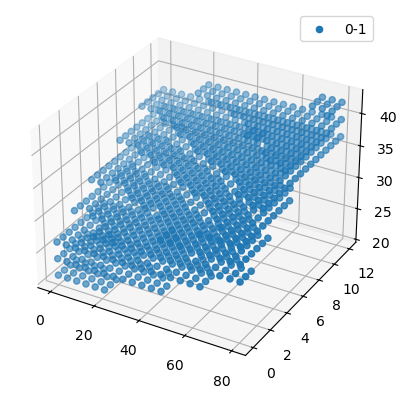

In [10]:
from sklearn.neighbors import KDTree
from collections import defaultdict

def find_boundary_points(points, labels, k=10):
    """
    Identify boundary points in a point cloud with labels using KDTree.
    
    Parameters
    ----------
    points : ndarray of shape (N, 3)
        3D coordinates of points
    labels : ndarray of shape (N,)
        Class labels (e.g. +1/-1 or multiclass)
    k : int
        Number of neighbors to check for label differences
    
    Returns
    -------
    boundaries : dict
        Dictionary where keys are (label_a, label_b) tuples and values 
        are arrays of boundary points lying between those classes.
    """
    tree = KDTree(points)
    boundaries = defaultdict(list)

    for i, p in enumerate(points):
        _, idx = tree.query([p], k=k)
        neighbor_labels = labels[idx[0]]
        
        # Compare with current point’s label
        current_label = labels[i]
        diff_labels = set(neighbor_labels) - {current_label}
        
        for other_label in diff_labels:
            key = tuple(sorted((current_label.item(), other_label.item())))
            boundaries[key].append(p)

    # Convert lists to numpy arrays
    return {k: np.array(v) for k, v in boundaries.items()}

boundaries = find_boundary_points(
    ds_result.design_space_grid.to_numpy()[:,[0,2,1]], 
    ds_result.phase_mean.to_numpy(), 
    k=16
)

for key, val in boundaries.items():
    print(f"Boundary {key}: {len(val)} points")

fig, ax = plt.subplots(subplot_kw={"projection":"3d"})
for key, points in boundaries.items():
    ax.scatter(
        points[:,0],
        points[:,1],
        points[:,2],
        label = "-".join(f"{k}" for k in key)
    )
ax.legend()
plt.show()

In [11]:
import torch
import torch.optim as optim

import matplotlib.pyplot as plt

from funcshape.surface import PointCloudSurface
from funcshape.transforms import SRNF
from funcshape.visual import plot_surface
    
from funcshape.networks import SurfaceReparametrizer
from funcshape.layers.sinefourier import SineFourierLayer
from funcshape.loss import SurfaceDistance
from funcshape.reparametrize import reparametrize
from funcshape.logging import Logger 
from funcshape.interpolation import linear_interpolate

f_01 = PointCloudSurface(boundaries[(0,1)])
f_12 = PointCloudSurface(boundaries[(1,2)])
fig, axs = plt.subplots(
    1,2,
    figsize=(5*2, 5), 
    subplot_kw = {"projection":"3d"}
)
plot_surface(f_01, ax = axs[0])
plot_surface(f_12, ax = axs[1])
for ax in axs:
    ax.set_xlim([0.0, 80.0])
    ax.set_ylim([0.0, 12.0])
    ax.set_zlim([0.0, 50.0])
plt.show()

KeyError: (1, 2)

Boundary (0, 1): 2269 points
Boundary (1, 2): 1435 points


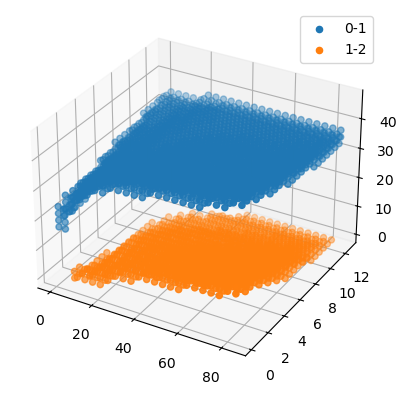

In [12]:
DIR = "/Users/knv2/Documents/codebase/AFL-tutorial/3DPhaseDiagram"
boundary_dataset = xr.load_dataset(DIR+'/dataset/250610-extrap_expand_dataset.nc')
xyz = boundary_dataset.composition.values.T[:,[0,2,1]]
flags = (xyz >= 0).all(axis=1)
xyz = xyz[flags,:]
ell = boundary_dataset.labels.values[flags]
ref_boundaries = find_boundary_points(xyz, ell, k=16)

for key, val in ref_boundaries.items():
    print(f"Boundary {key}: {len(val)} points")

fig, ax = plt.subplots(subplot_kw={"projection":"3d"})
for key, points in ref_boundaries.items():
    ax.scatter(
        points[:,0],
        points[:,1],
        points[:,2],
        label = "-".join(f"{k}" for k in key)
    )
ax.legend()
plt.show()

In [ ]:
ref_01 = PointCloudSurface(ref_boundaries[(0,1)])
ref_12 = PointCloudSurface(ref_boundaries[(1,2)])
fig, axs = plt.subplots(
    1,2,
    figsize=(5*2, 5), 
    subplot_kw = {"projection":"3d"}
)
plot_surface(ref_01, ax = axs[0])
plot_surface(ref_12, ax = axs[1])
for ax in axs:
    ax.set_xlim([0.0, 80.0])
    ax.set_ylim([0.0, 12.0])
    ax.set_zlim([0.0, 50.0])
plt.show()

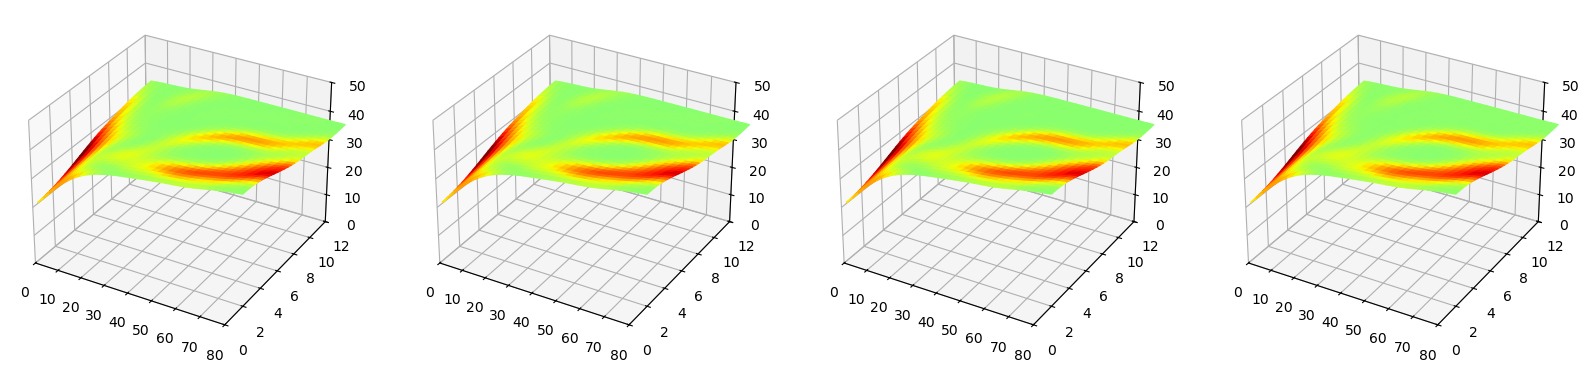

In [17]:
fig, axs = plt.subplots(
    1,4,
    figsize=(5*4, 5), 
    subplot_kw = {"projection":"3d"}
)
for i in range(4):
    surf = PointCloudSurface(ref_boundaries[(0,1)])
    plot_surface(surf, ax = axs[i])
for ax in axs:
    ax.set_xlim([0.0, 80.0])
    ax.set_ylim([0.0, 12.0])
    ax.set_zlim([0.0, 50.0])
plt.show()

In [19]:
query = PointCloudSurface(ref_boundaries[(0,1)])
ref = PointCloudSurface(ref_boundaries[(0,1)])
q = SRNF(query)
r = SRNF(ref)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Define reparametrization-network
RN = SurfaceReparametrizer(
    [SineFourierLayer(10) for _ in range(10)]
).to(device)
loss_func = SurfaceDistance(q, r, k=32, h=1e-4).to(device)

optimizer = optim.LBFGS(RN.parameters(), max_iter=30, line_search_fn="strong_wolfe")
errors = reparametrize(RN, loss_func, optimizer, 30, Logger(1))
RN.to("cpu"), loss_func.to("cpu"); # Need on CPU for plotting.
RN.detach()


[Iter     1] loss: 0.035021
[Iter     2] loss: 0.035021
Finished training in 4.27897s


In [15]:
from matplotlib.animation import FuncAnimation, PillowWriter

# --- Your existing setup ---
k = 30
X, Y = torch.meshgrid(torch.linspace(0, 1, k), torch.linspace(0, 1, k))
X, Y = X.reshape(-1, 1), Y.reshape(-1, 1)
X = torch.cat((X, Y), dim=1)
numsteps = 10

# Precompute all surfaces
surfaces = []
for h in linear_interpolate(lambda x: f_12(RN(x)), ref_12, numsteps):
    pts = h(X).detach().cpu().numpy()
    surfaces.append(PointCloudSurface(pts))

# --- Animation setup ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d")

def init():
    ax.set_xlim([0.0, 80.0])
    ax.set_ylim([0.0, 12.0])
    ax.set_zlim([0.0, 50.0])
    return []

def update(frame):
    ax.cla()  # Clear axis for new frame
    ax.set_xlim([0.0, 80.0])
    ax.set_ylim([0.0, 12.0])
    ax.set_zlim([0.0, 50.0])
    ax.set_title(f"Surface Evolution (t={frame})")

    # Plot initial surface (t=0) in grey
    plot_surface(surfaces[0], k=20, ax=ax, colormap=plt.get_cmap("gray"))

    # Plot current surface (t=frame) in color
    cmap = plt.get_cmap("jet")
    plot_surface(surfaces[frame], k=20, ax=ax, colormap=cmap)

    return []

# --- Create animation ---
anim = FuncAnimation(
    fig, update, frames=range(numsteps), init_func=init, blit=False
)

# --- Save as GIF ---
anim.save("surface_evolution.gif", writer=PillowWriter(fps=2))
plt.close(fig)

NameError: name 'f_12' is not defined

In [ ]:
import warnings, logging

def get_boundaries_geodesic_distance(grid, labels):
    boundaries = find_boundary_points(
        grid.to_numpy()[:,[0,2,1]], 
        labels.to_numpy(), 
        k=16
        )

    for key, val in boundaries.items():
        print(f"Boundary {key}: {len(val)} points")
    
    if not ref_boundaries.keys() == boundaries.keys():
        warnings.warn("Some phase boundaries are not resolved...")
    
    dists = {}
    for key, points in ref_boundaries.items():
        logging.info(f"Evaluation boundary {key}")
        ref = PointCloudSurface(points)
        try:
            query = PointCloudSurface(boundaries[key])
        except:
            logging.info(f"Phase boundary {key} is not resolved")
            dists[key] = None
            continue

        q = SRNF(query)
        r = SRNF(ref)

        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

        # Define reparametrization-network
        RN = SurfaceReparametrizer(
            [SineFourierLayer(10) for _ in range(10)]
        ).to(device)
        loss_func = SurfaceDistance(q, r, k=32, h=1e-4).to(device)

        optimizer = optim.LBFGS(RN.parameters(), max_iter=30, line_search_fn="strong_wolfe")
        errors = reparametrize(RN, loss_func, optimizer, 30, Logger(1))
        RN.to("cpu"), loss_func.to("cpu"); # Need on CPU for plotting.
        RN.detach()
        dists[key] = errors[-1].item()

    return dists

In [ ]:
get_boundaries_geodesic_distance(
    ds_result.design_space_grid, 
    ds_result.phase_mean
    )

Boundary (0, 1): 844 points
Boundary (1, 2): 281 points
[Iter     1] loss: 390.070345
[Iter     2] loss: 390.072242
Finished training in 5.09252s
[Iter     1] loss: 215.283618
[Iter     2] loss: 210.965022
[Iter     3] loss: 210.961662
[Iter     4] loss: 210.961662
Finished training in 12.40928s


{(0, 1): 390.0722422701563, (1, 2): 210.96166193708072}